# Homologous recombination events

In [1]:
# set working directory to project folder
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import plotly.io as pio
pio.renderers.default = "browser" 

import altair as alt
from itertools import combinations
import numpy as np
import math
import pypangraph as pp
from Bio import Phylo, SeqIO, AlignIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

import random
import plotly.graph_objects as go
import plotly.express as px

import scipy.cluster.hierarchy as sch
from collections import defaultdict, deque, Counter
from Bio import Phylo

from pathlib import Path
import subprocess

from Bio.Phylo.TreeConstruction import DistanceCalculator
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

from junction_analysis.helpers import get_tree_order, cluster_by_tree, strip_newick_suffixes, write_shared_nodes_fasta, simplify_cluster_keys, count_trna_per_junction, get_core_alignment_lengths, core_block_snp_gaps, add_singleton_gain_loss_isolate_columns, add_singleton_has_own_cluster, add_binary_event_info, compare_consensus_paths
from junction_analysis.junction_trees import build_tree_from_block_list, compute_pairwise_distances, cluster_tree_by_branch_length
import junction_analysis.pangraph_utils as pu
from junction_analysis.plotting import plot_junction_pangraph_interactive, plot_block_distance_distribution, plot_pairwise_distance_hist, plot_event_counts_distribution, plot_events_per_junction, plot_cluster_count_distribution, plot_event_length_distribution, plot_cluster_count_vs_diversity, plot_marginal_scatter, plot_all_junctions_pairwise_distances, plot_snp_position_cdfs, plot_snp_gap_histogram, plot_core_alignment_lengths, plot_scatter, plot_path_comparison_lengths
from junction_analysis.consensus import find_consensus_paths, make_deduplicated_paths, consensus_paths_and_assignments, find_consensus_paths_core, cluster_map_to_dataframe, collect_all_pairwise_distances, save_consensus_cache, collect_all_branch_lengths
from junction_analysis.block_alignment import create_block_msas, summarize_block_msas, analyze_alignment, cluster_alignment, retrieve_cluster_assignments
from junction_analysis.annotate_insertions import get_insertions_deletions_from_consensus, write_insertions_fasta, summarize_deletions_consensus, load_all_deletions_summaries, summarize_inversions_consensus, summarize_translocations_consensus, write_insertions_fasta, load_all_insertions_summaries, load_all_inversions_summaries, load_all_translocations_summaries, combine_all_junctions_summaries, count_events_per_junction, deduplicate_events, summarize_ambiguous_insertions, load_all_ambiguous_insertions_summaries

### Are events in binary junctions associated with homologous recombinations and are they consistant with our clustering approach

In [11]:
#jdf_all = add_singleton_gain_loss_isolate_columns(jdf_all, pangraph_dir="../results/junction_pangraphs")
#cluster_df = pd.read_csv("../results/consensus_analysis/cluster_maps_0_001.csv")
#jdf_all = add_singleton_has_own_cluster(jdf_all, cluster_df)
#jdf_all.to_csv("../results/junction_summary_df.csv", index=False)

jdf_all = pd.read_csv("../results/junction_summary_df.csv")
jdf_all

,junction_name,n_iso,n_blocks,has_dupl,n_categories,majority_category,singleton,cat_entropy,n_nodes,min_length,...,mean_length_translocation,mean_length_inversion,mean_event_length,block_ji_dist,edge_ji_dist,has_singleton_gain,has_singleton_loss,singleton_gain_isolate,singleton_loss_isolate,singleton_has_own_cluster
0,HUTOPWFGVH_f__WJBYSSJHSE_f,222,5,False,3,218,False,0.100354,11,18176,...,0.0,0.0,744.000000,0.991064,0.973218,NaN,NaN,NaN,NaN,NaN
1,IZQZNHJQRQ_f__ZVPGGEJIIF_f,222,3,False,2,221,True,0.028831,5,11739,...,0.0,0.0,777.000000,0.996997,0.990991,True,False,NZ_CP051615.1,NaN,False
2,JNLRGIQXOF_f__YQUHGDANHE_f,222,3,False,2,221,True,0.028831,5,27949,...,0.0,0.0,1437.000000,0.996997,0.990991,True,False,NZ_AP022362.1,NaN,False
3,JMOMDSHCBS_r__SPDPCYMYDN_r,222,3,False,2,220,False,0.051397,5,7364,...,0.0,0.0,777.000000,0.994021,0.982064,NaN,NaN,NaN,NaN,NaN
4,JKRDVEYDGL_f__OTPJRRWJRK_f,222,3,False,2,221,True,0.028831,5,10056,...,0.0,0.0,38175.000000,0.996997,0.990991,True,False,NZ_CP032201.1,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
513,PLTCZQCVRD_f__RYYAQMEJGY_f,3,48,True,3,1,False,1.098612,80,101503,...,3366.0,0.0,7118.870968,0.138971,0.058489,NaN,NaN,NaN,NaN,NaN
514,DSLXSJZSTL_r__KGJXRPELGX_f,2,7,True,2,1,True,0.693147,20,17091,...,0.0,0.0,3420.000000,0.818182,0.800000,NaN,NaN,NaN,NaN,NaN
515,GPXHVRRZLC_f__KYQOKYBCOW_f,2,8,False,2,1,True,0.693147,12,65779,...,0.0,0.0,0.000000,0.500000,0.000000,NaN,NaN,NaN,NaN,NaN
516,XXIWNZXZTK_f__ZLAJFQLBFQ_r,2,3,False,2,1,True,0.693147,6,83629,...,0.0,0.0,0.000000,0.500000,0.000000,NaN,NaN,NaN,NaN,NaN


In [25]:
jdf_singleton = jdf_all[jdf_all['singleton'] == True]
jdf_all[jdf_all['singleton_has_own_cluster'] == True]


,junction_name,n_iso,n_blocks,has_dupl,n_categories,majority_category,singleton,cat_entropy,n_nodes,min_length,...,mean_length_translocation,mean_length_inversion,mean_event_length,block_ji_dist,edge_ji_dist,has_singleton_gain,has_singleton_loss,singleton_gain_isolate,singleton_loss_isolate,singleton_has_own_cluster
24,ISADOQMCVR_r__JKXDSPORHF_r,222,3,True,2,221,True,0.028831,7,7855,...,0.0,0.0,0.0,0.997748,0.996997,True,False,NZ_CP116085.1,NaN,True
107,IFRPFFEGON_f__LSBXOCNNHO_f,222,3,False,2,221,True,0.028831,5,4258,...,0.0,0.0,0.0,0.996997,0.990991,True,False,NZ_CP107142.1,NaN,True
240,LWRCACRWJW_r__PIVHURLJVP_r,222,3,False,2,221,True,0.028831,5,9756,...,0.0,0.0,0.0,0.996997,0.990991,False,True,NaN,NZ_CP116085.1,True
418,GAKJONQISG_r__UJBGATQZSS_r,222,4,False,2,221,True,0.028831,6,2354,...,0.0,0.0,0.0,0.995495,0.990991,True,True,NZ_CP116085.1,NZ_CP116085.1,True
420,FZZJSRRGUR_r__WNLYKTZGKW_r,222,4,False,2,221,True,0.028831,6,1903,...,0.0,0.0,0.0,0.995495,0.990991,True,True,NZ_CP015074.2,NZ_CP015074.2,True
437,DGMGBEYIHM_f__JVDYVQZUBR_f,222,3,False,2,221,True,0.028831,5,10012,...,0.0,0.0,0.0,0.996997,0.990991,True,False,NZ_CP116085.1,NaN,True


In [ ]:
# Percentage of single events associated with their own cluster --> potential homologous recombination
len(jdf_all[jdf_all['singleton_has_own_cluster'] == True]) / len(jdf_all[~jdf_all["singleton_has_own_cluster"].isna()]) * 100

2.197802197802198

In [9]:
jdf_singleton[~jdf_singleton["singleton_loss_isolate"].isna()]

,junction_name,n_iso,n_blocks,has_dupl,n_categories,majority_category,singleton,cat_entropy,n_nodes,min_length,...,mean_length_deletion,mean_length_translocation,mean_length_inversion,mean_event_length,block_ji_dist,edge_ji_dist,has_singleton_gain,has_singleton_loss,singleton_gain_isolate,singleton_loss_isolate
72,HLZGFRDRSW_r__SYQZDBITDR_r,222,4,False,2,221,True,0.028831,6,40105,...,612.0,0.0,0.0,690.0,0.995495,0.990991,True,True,NZ_CP072980.1,NZ_CP072980.1
74,HLDRILYIZH_r__YSKQIEWBCG_r,222,4,False,2,221,True,0.028831,6,10985,...,841.0,0.0,0.0,804.0,0.995495,0.990991,True,True,NZ_CP051615.1,NZ_CP051615.1
94,HUIGUZLHBJ_r__YRROIHFKBD_f,222,3,False,2,221,True,0.028831,5,41243,...,608.0,0.0,0.0,608.0,0.996997,0.990991,False,True,<NA>,NZ_CP054219.1
123,KUDTBWWBJE_f__YSEMYTMKWD_f,222,4,False,2,221,True,0.028831,6,6802,...,510.0,0.0,0.0,639.0,0.995495,0.990991,True,True,NZ_CP124455.1,NZ_CP124455.1
160,QQLFXKORNH_r__TUJRNXXQZV_r,222,3,False,2,221,True,0.028831,5,8260,...,0.0,0.0,0.0,0.0,0.996997,0.990991,False,True,<NA>,NZ_CP021207.1
164,QLKLQMYUEK_f__SVGDCUWZRJ_f,222,3,False,2,221,True,0.028831,5,69126,...,0.0,0.0,0.0,0.0,0.996997,0.990991,False,True,<NA>,NZ_CP124517.1
171,PUSHEQNFCL_r__WFTVPHITVT_r,222,3,False,2,221,True,0.028831,5,12853,...,430.0,0.0,0.0,430.0,0.996997,0.990991,False,True,<NA>,NZ_CP015076.1
228,MRDJEEINGI_f__PHTUBOWZWA_r,222,4,False,2,221,True,0.028831,6,5378,...,1445.0,0.0,0.0,1106.5,0.995495,0.990991,True,True,NZ_CP029576.1,NZ_CP029576.1
230,MPNWYFWMOG_r__RNYSWPAVAU_r,222,3,False,2,221,True,0.028831,5,16888,...,358.0,0.0,0.0,358.0,0.996997,0.990991,False,True,<NA>,NZ_CP128907.1
234,MFKARJGFFB_f__UNPTZNKWVD_f,222,3,False,2,221,True,0.028831,5,21674,...,1572.0,0.0,0.0,1572.0,0.996997,0.990991,False,True,<NA>,NZ_CP095520.1


In [ ]:
# non-singleton junctions
jdf_all[(jdf_all['singleton'] == False) & (jdf_all['n_categories'] == 2)]

,junction_name,n_iso,n_blocks,has_dupl,n_categories,majority_category,singleton,cat_entropy,n_nodes,min_length,...,mean_length_translocation,mean_length_inversion,mean_event_length,block_ji_dist,edge_ji_dist,has_singleton_gain,has_singleton_loss,singleton_gain_isolate,singleton_loss_isolate,singleton_has_own_cluster
3,JMOMDSHCBS_r__SPDPCYMYDN_r,222,3,False,2,220,False,0.051397,5,7364,...,0.0,0.0,777.0,0.994021,0.982064,NaN,NaN,NaN,NaN,NaN
20,IXLMXEMXWI_r__XRXZJDDTTM_r,222,3,False,2,218,False,0.090222,5,29821,...,0.0,0.0,776.0,0.988151,0.964453,NaN,NaN,NaN,NaN,NaN
21,IWNOJXIDQP_r__KCBEPSEUCA_f,222,3,False,2,220,False,0.051397,5,14408,...,0.0,0.0,777.0,0.994021,0.982064,NaN,NaN,NaN,NaN,NaN
25,ISADOQMCVR_f__QHGKDXJCDB_f,222,3,False,2,214,False,0.155135,5,20543,...,0.0,0.0,0.0,0.976737,0.930211,NaN,NaN,NaN,NaN,NaN
31,QXRGVLICMC_r__RQUTOCWADD_r,222,3,False,2,220,False,0.051397,5,4375,...,0.0,0.0,777.0,0.994021,0.982064,NaN,NaN,NaN,NaN,NaN
35,KLARMMLEPU_f__OJTZQVKWWG_r,222,3,False,2,220,False,0.051397,5,40780,...,0.0,0.0,1253.0,0.994021,0.982064,NaN,NaN,NaN,NaN,NaN
37,RYJVCTXEHC_r__STVEZQVFDI_r,222,3,False,2,220,False,0.051397,5,13875,...,0.0,0.0,773.0,0.994021,0.982064,NaN,NaN,NaN,NaN,NaN
64,HHRCVCXKIA_r__TJDPHITKZG_r,222,3,False,2,219,False,0.071585,5,15397,...,0.0,0.0,777.0,0.991073,0.973218,NaN,NaN,NaN,NaN,NaN
77,HKKMVAAVLK_f__YXFAUSIPGJ_r,222,3,False,2,173,False,0.527819,5,4744,...,0.0,0.0,0.0,0.884812,0.654437,NaN,NaN,NaN,NaN,NaN
103,IHERCMJOSU_f__JJRRWBDVGH_f,222,3,False,2,199,False,0.332930,5,26445,...,0.0,0.0,1446.0,0.937807,0.813420,NaN,NaN,NaN,NaN,NaN


In [13]:
cluster_df = pd.read_csv("../results/consensus_analysis/cluster_maps_0_001.csv")

# detection is not perfect, if an event doesnt have its own cluster but two own clusters, binary_gain_has_own_cluster and binary_loss_has_own_cluster can be False even though there is an association with a homologous recombination, that's why I just further investigated every case where binary_loss/gain_in_multiple_clusters is True
# if a gain is in several cluster it could actually just be a loss, if a loss is in several cluster it could actually just be a gain --> in these cases investigate
# if its part of a cluster but doesn't have its own cluster than its probably correctly classified or frequency is just as good as it can be
jdf_all = add_binary_event_info(jdf_all, cluster_df)


In [39]:
jdf_all[(jdf_all['singleton'] == False) & (jdf_all['n_categories'] == 2)].binary_event_type.value_counts()

binary_event_type
gain             39
loss              7
gain_and_loss     3
Name: count, dtype: int64

In [15]:
jdf_all[(jdf_all['singleton'] == False) & (jdf_all['n_categories'] == 2) & (jdf_all["binary_loss_has_own_cluster"] == True)]

,junction_name,n_iso,n_blocks,has_dupl,n_categories,majority_category,singleton,cat_entropy,n_nodes,min_length,...,binary_gain_isolates,binary_loss_isolates,binary_event_type,binary_gain_frequency,binary_loss_frequency,binary_gain_has_own_cluster,binary_loss_has_own_cluster,binary_gain_in_multiple_clusters,binary_loss_in_multiple_clusters,binary_event_in_multiple_clusters
383,VCAVVOUNDI_f__XIWJABIXEM_f,222,3,False,2,170,False,0.544342,5,5907,...,<NA>,"NZ_AP022171.1,NZ_CP015069.1,NZ_CP015074.2,NZ_C...",loss,<NA>,52,<NA>,True,<NA>,False,False


In [53]:
jdf_all[(jdf_all['singleton'] == False) & (jdf_all['n_categories'] == 2) & (jdf_all["binary_event_in_multiple_clusters"] == True)]

,junction_name,n_iso,n_blocks,has_dupl,n_categories,majority_category,singleton,cat_entropy,n_nodes,min_length,...,binary_gain_isolates,binary_loss_isolates,binary_event_type,binary_gain_frequency,binary_loss_frequency,binary_gain_has_own_cluster,binary_loss_has_own_cluster,binary_gain_in_multiple_clusters,binary_loss_in_multiple_clusters,binary_event_in_multiple_clusters
37,RYJVCTXEHC_r__STVEZQVFDI_r,222,3,False,2,220,False,0.051397,5,13875,...,"NZ_CP010876.1,NZ_CP098219.1",<NA>,gain,2,<NA>,False,<NA>,True,<NA>,True
121,RTZVEJWRIR_r__UHYGUNDBFL_r,222,3,False,2,162,False,0.583527,5,13360,...,<NA>,"NZ_AP022171.1,NZ_CP014488.1,NZ_CP015069.1,NZ_C...",loss,<NA>,60,<NA>,False,<NA>,True,True
196,LELSLSXUJD_f__MXGPCKRKDO_f,222,4,False,2,150,False,0.630086,6,32352,...,"NZ_AP018784.1,NZ_AP022171.1,NZ_CP014488.1,NZ_C...","NZ_AP018784.1,NZ_AP022171.1,NZ_CP014488.1,NZ_C...",gain_and_loss,72,72,False,False,True,True,True
427,VRDEBAMMSO_r__WXCHSHHCDT_r,222,3,False,2,168,False,0.554790,5,5181,...,<NA>,"NZ_AP022171.1,NZ_CP015069.1,NZ_CP015074.2,NZ_C...",loss,<NA>,54,<NA>,False,<NA>,True,True
447,DAUXXHIOJT_f__LELSLSXUJD_f,222,3,False,2,150,False,0.630086,5,16127,...,<NA>,"NZ_AP018784.1,NZ_AP022171.1,NZ_CP014488.1,NZ_C...",loss,<NA>,72,<NA>,False,<NA>,True,True


In [ ]:
# for junctions with a single cluster we would have to reconstruct along the tree if they are insertions or deletions
jdf_all[(jdf_all['singleton'] == False) & (jdf_all['n_categories'] == 2) & (jdf_all['n_clusters'] == 1)]

,junction_name,n_iso,n_blocks,has_dupl,n_categories,majority_category,singleton,cat_entropy,n_nodes,min_length,...,binary_gain_isolates,binary_loss_isolates,binary_event_type,binary_gain_frequency,binary_loss_frequency,binary_gain_has_own_cluster,binary_loss_has_own_cluster,binary_gain_in_multiple_clusters,binary_loss_in_multiple_clusters,binary_event_in_multiple_clusters
3,JMOMDSHCBS_r__SPDPCYMYDN_r,222,3,False,2,220,False,0.051397,5,7364,...,"NZ_CP010876.1,NZ_CP051609.1",<NA>,gain,2,<NA>,False,<NA>,False,<NA>,False
20,IXLMXEMXWI_r__XRXZJDDTTM_r,222,3,False,2,218,False,0.090222,5,29821,...,"NZ_CP035476.1,NZ_CP035477.1,NZ_CP035516.1,NZ_C...",<NA>,gain,4,<NA>,False,<NA>,False,<NA>,False
21,IWNOJXIDQP_r__KCBEPSEUCA_f,222,3,False,2,220,False,0.051397,5,14408,...,"NZ_CP124415.1,NZ_CP124429.1",<NA>,gain,2,<NA>,False,<NA>,False,<NA>,False
31,QXRGVLICMC_r__RQUTOCWADD_r,222,3,False,2,220,False,0.051397,5,4375,...,"NZ_CP049077.2,NZ_CP103755.1",<NA>,gain,2,<NA>,False,<NA>,False,<NA>,False
64,HHRCVCXKIA_r__TJDPHITKZG_r,222,3,False,2,219,False,0.071585,5,15397,...,"NZ_CP124320.1,NZ_CP124498.1,NZ_CP124500.1",<NA>,gain,3,<NA>,False,<NA>,False,<NA>,False
77,HKKMVAAVLK_f__YXFAUSIPGJ_r,222,3,False,2,173,False,0.527819,5,4744,...,"NZ_AP018784.1,NZ_AP022171.1,NZ_CP013831.1,NZ_C...",<NA>,gain,49,<NA>,False,<NA>,False,<NA>,False
103,IHERCMJOSU_f__JJRRWBDVGH_f,222,3,False,2,199,False,0.332930,5,26445,...,"NZ_AP021998.1,NZ_AP022032.1,NZ_AP022064.1,NZ_A...",<NA>,gain,23,<NA>,False,<NA>,False,<NA>,False
125,OURQVJZAZZ_f__UTYAQKFQDH_f,222,4,False,2,201,False,0.313041,6,2212,...,"NZ_AP022171.1,NZ_CP097360.1,NZ_CP115390.1,NZ_C...","NZ_AP022171.1,NZ_CP097360.1,NZ_CP115390.1,NZ_C...",gain_and_loss,21,21,False,False,False,False,False
141,NXMETPNVGP_r__YOCIMVGHSL_r,222,3,False,2,214,False,0.155135,5,3318,...,"NZ_CP124328.1,NZ_CP124332.1,NZ_CP124334.1,NZ_C...",<NA>,gain,8,<NA>,False,<NA>,False,<NA>,False
174,PNGMFIQRPL_r__XKCACMGLJG_f,222,3,False,2,220,False,0.051397,5,37566,...,"NZ_OX637959.1,NZ_OX637961.1",<NA>,gain,2,<NA>,False,<NA>,False,<NA>,False


### How does length change between homologous recombinations
how much diversity does each homologous recombination bring on average, compare only consensus paths


In [56]:
jdf_all = pd.read_csv("../results/junction_summary_df.csv")

clustering_results = {}
consensus_paths = {}


for junction_id in jdf_all["junction_name"].tolist():
    print(junction_id)
    cluster_map_core, consensus_paths_core, path_dict, consensus_paths_plotting, assignment_df_plotting, all_root_states, all_root_states_unqiue, ambiguity_stats_df, dedup_stats_df = find_consensus_paths_core(junction_id, plot_consensus=False, plot_pair_dist=False, plot_snp_dist= False, plot_ambiguities= False, clustering_bl_thresh=0.001, consensus_criterium='core_genome_tree', tree_path='../config/polished_tree.nwk')
    clustering_results[junction_id] = cluster_map_core
    consensus_paths[junction_id] = consensus_paths_core
    


HUTOPWFGVH_f__WJBYSSJHSE_f
Skipping core: FASTA, alignment and tree already exist in /Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/results/consensus_analysis/HUTOPWFGVH_f__WJBYSSJHSE_f
[{1}, {1}, {1}, {0}, {0}]
No ambiguous blocks.
170 / 170 isolates share the majority path
[{1}, {1}, {1}]
No ambiguous blocks.
52 / 52 isolates share the majority path
IZQZNHJQRQ_f__ZVPGGEJIIF_f
Skipping core: FASTA, alignment and tree already exist in /Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/results/consensus_analysis/IZQZNHJQRQ_f__ZVPGGEJIIF_f
[{1}, {1}, {0}]
No ambiguous blocks.
222 / 222 isolates share the majority path
JNLRGIQXOF_f__YQUHGDANHE_f
Skipping core: FASTA, alignment and tree already exist in /Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/results/consensus_analysis/JNLRGIQXOF_f__YQUHGDANHE_f
[{1}, {1}, {0}]
No ambiguous blocks.
169 / 169 isolates share the majority path
[{1}, {1}]
No ambiguous blocks.
1 / 1 (single isolate)
[{

In [9]:
jdf_all

,junction_name,n_iso,n_blocks,has_dupl,n_categories,majority_category,singleton,cat_entropy,n_nodes,min_length,...,mean_length_translocation,mean_length_inversion,mean_event_length,block_ji_dist,edge_ji_dist,has_singleton_gain,has_singleton_loss,singleton_gain_isolate,singleton_loss_isolate,singleton_has_own_cluster
0,HUTOPWFGVH_f__WJBYSSJHSE_f,222,5,False,3,218,False,0.100354,11,18176,...,0.0,0.0,744.000000,0.991064,0.973218,NaN,NaN,NaN,NaN,NaN
1,IZQZNHJQRQ_f__ZVPGGEJIIF_f,222,3,False,2,221,True,0.028831,5,11739,...,0.0,0.0,777.000000,0.996997,0.990991,True,False,NZ_CP051615.1,NaN,False
2,JNLRGIQXOF_f__YQUHGDANHE_f,222,3,False,2,221,True,0.028831,5,27949,...,0.0,0.0,1437.000000,0.996997,0.990991,True,False,NZ_AP022362.1,NaN,False
3,JMOMDSHCBS_r__SPDPCYMYDN_r,222,3,False,2,220,False,0.051397,5,7364,...,0.0,0.0,777.000000,0.994021,0.982064,NaN,NaN,NaN,NaN,NaN
4,JKRDVEYDGL_f__OTPJRRWJRK_f,222,3,False,2,221,True,0.028831,5,10056,...,0.0,0.0,38175.000000,0.996997,0.990991,True,False,NZ_CP032201.1,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
513,PLTCZQCVRD_f__RYYAQMEJGY_f,3,48,True,3,1,False,1.098612,80,101503,...,3366.0,0.0,7118.870968,0.138971,0.058489,NaN,NaN,NaN,NaN,NaN
514,DSLXSJZSTL_r__KGJXRPELGX_f,2,7,True,2,1,True,0.693147,20,17091,...,0.0,0.0,3420.000000,0.818182,0.800000,NaN,NaN,NaN,NaN,NaN
515,GPXHVRRZLC_f__KYQOKYBCOW_f,2,8,False,2,1,True,0.693147,12,65779,...,0.0,0.0,0.000000,0.500000,0.000000,NaN,NaN,NaN,NaN,NaN
516,XXIWNZXZTK_f__ZLAJFQLBFQ_r,2,3,False,2,1,True,0.693147,6,83629,...,0.0,0.0,0.000000,0.500000,0.000000,NaN,NaN,NaN,NaN,NaN


In [7]:
jdf_all = pd.read_csv("../results/junction_summary_df.csv")
len(jdf_all[jdf_all['n_clusters'] == 2]['junction_name'].tolist())

154

In [8]:
jdf_all[jdf_all['n_clusters'] == 2]

,junction_name,n_iso,n_blocks,has_dupl,n_categories,majority_category,singleton,cat_entropy,n_nodes,min_length,...,mean_length_translocation,mean_length_inversion,mean_event_length,block_ji_dist,edge_ji_dist,has_singleton_gain,has_singleton_loss,singleton_gain_isolate,singleton_loss_isolate,singleton_has_own_cluster
0,HUTOPWFGVH_f__WJBYSSJHSE_f,222,5,False,3,218,False,0.100354,11,18176,...,0.0,0.0,744.00000,0.991064,0.973218,NaN,NaN,NaN,NaN,NaN
4,JKRDVEYDGL_f__OTPJRRWJRK_f,222,3,False,2,221,True,0.028831,5,10056,...,0.0,0.0,38175.00000,0.996997,0.990991,True,False,NZ_CP032201.1,NaN,False
6,JJDDCMJGQE_r__ZUHGCANVTN_r,222,5,False,4,218,False,0.108956,19,19806,...,0.0,0.0,777.00000,0.992891,0.978497,NaN,NaN,NaN,NaN,NaN
7,JJDDCMJGQE_f__PJYKOTQZCQ_f,222,4,False,3,220,False,0.057641,11,10532,...,0.0,0.0,772.00000,0.995500,0.986507,NaN,NaN,NaN,NaN,NaN
11,JDUTVQBTFB_r__OPCCUBTDFQ_r,222,3,False,2,221,True,0.028831,5,26413,...,0.0,0.0,1254.00000,0.996997,0.990991,True,False,NZ_CP051659.1,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
504,SKPHAXSFLS_f__TORJAESOXF_f,220,39,True,6,213,False,0.190319,113,8240,...,0.0,0.0,35476.62500,0.971164,0.964751,NaN,NaN,NaN,NaN,NaN
507,CYGJWOEQKN_r__EOBHADSLFU_r,220,3,False,2,212,False,0.156210,5,1312,...,0.0,0.0,777.00000,0.976532,0.929597,NaN,NaN,NaN,NaN,NaN
509,JVNRLCFAVD_f__PLTCZQCVRD_r,218,254,True,68,89,False,2.777543,6502,68292,...,0.0,0.0,73759.46281,0.583336,0.570138,NaN,NaN,NaN,NaN,NaN
512,JVNRLCFAVD_f__ZTHKZYHPIX_f,3,24,True,3,1,False,1.098612,60,67126,...,0.0,0.0,79725.00000,0.340532,0.169312,NaN,NaN,NaN,NaN,NaN


In [ ]:
rows = []                                                                                                                                                                                                 
for junction_name in jdf_all[jdf_all['n_clusters'] == 2]['junction_name'].tolist():                                                                                                                                
    try:
        vals = list(consensus_paths[junction_name].values())                                                                                                                                                                                                                                                                                                                        
        result = compare_consensus_paths(
            vals[0], vals[1],                                                                                                                         
            junction_name=junction_name,
            cluster1="consensus_1", cluster2="consensus_2",
            base_alignment_dir="../results/block_alignments",                                                                                                                                             
        )                                                                                                                                                                                                 
        rows.append(result)                                                                                                                                                                               
    except Exception as e:                                                                                                                                                                                
        print(f"Skipping {junction_name}: {e}")
                                                                                                                                                                                                        
path_comparison_df = pd.DataFrame(rows)     


path_comparison_df['exclusive_length'] = path_comparison_df['exclusive_length_1'] + path_comparison_df['exclusive_length_2']
path_comparison_df['n_exclusive_blocks'] = path_comparison_df['n_exclusive_blocks_1'] + path_comparison_df['n_exclusive_blocks_2']   
path_comparison_df.to_csv("../results/consensus_analysis/length_between_clusters.csv", index=False)  

In [2]:
# 130 out 0f 154 junctions with only two clusters have the same block structure in both consensus paths and 0 non-shared accessory genome length                                                                   
path_comparison_df = pd.read_csv("../results/consensus_analysis/length_between_clusters.csv")
path_comparison_df

,junction_name,cluster1,cluster2,n_shared_blocks,n_exclusive_blocks_1,n_exclusive_blocks_2,shared_length,exclusive_length_1,exclusive_length_2,exclusive_length,n_exclusive_blocks
0,HUTOPWFGVH_f__WJBYSSJHSE_f,consensus_1,consensus_2,3,0,0,18177,0,0,0,0
1,JKRDVEYDGL_f__OTPJRRWJRK_f,consensus_1,consensus_2,2,0,0,10063,0,0,0,0
2,JJDDCMJGQE_r__ZUHGCANVTN_r,consensus_1,consensus_2,4,0,0,19832,0,0,0,0
3,JJDDCMJGQE_f__PJYKOTQZCQ_f,consensus_1,consensus_2,3,0,0,10557,0,0,0,0
4,JDUTVQBTFB_r__OPCCUBTDFQ_r,consensus_1,consensus_2,2,0,0,26417,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
149,SKPHAXSFLS_f__TORJAESOXF_f,consensus_1,consensus_2,8,0,0,8379,0,0,0,0
150,CYGJWOEQKN_r__EOBHADSLFU_r,consensus_1,consensus_2,2,0,0,1322,0,0,0,0
151,JVNRLCFAVD_f__PLTCZQCVRD_r,consensus_1,consensus_2,37,2,1,90173,2172,2254,4426,3
152,JVNRLCFAVD_f__ZTHKZYHPIX_f,consensus_1,consensus_2,6,4,15,60161,5722,59349,65071,19


In [88]:
path_comparison_df[path_comparison_df['exclusive_length'] > 0]

,junction_name,cluster1,cluster2,n_shared_blocks,n_exclusive_blocks_1,n_exclusive_blocks_2,shared_length,exclusive_length_1,exclusive_length_2,exclusive_length,n_exclusive_blocks
19,HMGOSWQWLP_r__SHLDLTAVZA_r,consensus_1,consensus_2,12,0,3,23777,0,576,576,3
22,HLLLVEXLHF_r__NBVDTPUFKL_f,consensus_1,consensus_2,3,3,2,13257,8686,12703,21389,5
33,ILYDRBOPRK_r__JRRJHZVADX_r,consensus_1,consensus_2,6,1,1,7004,395,395,790,2
37,IFRPFFEGON_f__LSBXOCNNHO_f,consensus_1,consensus_2,2,0,1,4282,0,2540,2540,1
39,IAMXLIYGOQ_r__WXGURNWKVZ_r,consensus_1,consensus_2,3,1,1,13258,627,1043,1670,2
47,QSECVMMRIA_r__ZIFDFWWRCE_f,consensus_1,consensus_2,3,0,1,1980,0,786,786,1
67,LRPZIYPPND_r__VTCLZJNIFI_f,consensus_1,consensus_2,3,2,2,14562,430,600,1030,4
77,BTXAZDJJLH_r__GOSFXHIPVD_r,consensus_1,consensus_2,2,0,1,2455,0,2590,2590,1
87,CIRMBUYJFK_f__CWCCKOQCWZ_r,consensus_1,consensus_2,10,22,0,21926,42923,0,42923,22
100,AGVTAJTYER_r__OZLYYMOKWU_f,consensus_1,consensus_2,2,0,1,1915,0,777,777,1


In [5]:
print(path_comparison_df.exclusive_length.mean())
print(path_comparison_df.exclusive_length.std())

print(path_comparison_df[path_comparison_df['exclusive_length'] > 0].exclusive_length.median())
print(path_comparison_df[path_comparison_df['exclusive_length'] > 0].exclusive_length.quantile(0.25))
print(path_comparison_df[path_comparison_df['exclusive_length'] > 0].exclusive_length.quantile(0.75))

1949.7337662337663
9015.951598656124
2565.0
789.0
12454.5


In [83]:
jdf_all[jdf_all['junction_name'].isin(path_comparison_df[path_comparison_df['exclusive_length'] > 0].junction_name.to_list())]

,junction_name,n_iso,n_blocks,has_dupl,n_categories,majority_category,singleton,cat_entropy,n_nodes,min_length,...,mean_length_translocation,mean_length_inversion,mean_event_length,block_ji_dist,edge_ji_dist,has_singleton_gain,has_singleton_loss,singleton_gain_isolate,singleton_loss_isolate,singleton_has_own_cluster
70,HMGOSWQWLP_r__SHLDLTAVZA_r,222,12,True,9,91,False,1.267409,118,22139,...,0.000000,0.0,1279.500000,0.719828,0.742021,NaN,NaN,NaN,NaN,NaN
73,HLLLVEXLHF_r__NBVDTPUFKL_f,222,12,False,6,166,False,0.700104,38,21941,...,0.000000,0.0,9474.000000,0.768643,0.669079,NaN,NaN,NaN,NaN,NaN
96,ILYDRBOPRK_r__JRRJHZVADX_r,222,11,True,23,130,False,1.570526,184,6544,...,0.000000,0.0,1265.550000,0.639466,0.560630,NaN,NaN,NaN,NaN,NaN
107,IFRPFFEGON_f__LSBXOCNNHO_f,222,3,False,2,221,True,0.028831,5,4258,...,0.000000,0.0,0.000000,0.996997,0.990991,True,False,NZ_CP107142.1,NaN,True
114,IAMXLIYGOQ_r__WXGURNWKVZ_r,222,6,False,3,169,False,0.571968,13,13883,...,0.000000,0.0,1253.000000,0.854266,0.707154,NaN,NaN,NaN,NaN,NaN
158,QSECVMMRIA_r__ZIFDFWWRCE_f,222,5,False,4,169,False,0.610153,16,1969,...,0.000000,0.0,1525.000000,0.905819,0.720898,NaN,NaN,NaN,NaN,NaN
213,LRPZIYPPND_r__VTCLZJNIFI_f,222,4,True,4,110,False,0.783328,17,14425,...,0.000000,0.0,300.000000,0.709870,0.696574,NaN,NaN,NaN,NaN,NaN
255,BTXAZDJJLH_r__GOSFXHIPVD_r,222,3,False,2,170,False,0.544342,5,2452,...,0.000000,0.0,0.000000,0.879880,0.639640,NaN,NaN,NaN,NaN,NaN
289,CIRMBUYJFK_f__CWCCKOQCWZ_r,222,41,True,33,129,False,1.600482,1004,21762,...,0.000000,0.0,3515.702703,0.729658,0.686548,NaN,NaN,NaN,NaN,NaN
328,AGVTAJTYER_r__OZLYYMOKWU_f,222,3,False,3,220,False,0.057641,8,1792,...,0.000000,0.0,760.000000,0.994001,0.982023,NaN,NaN,NaN,NaN,NaN


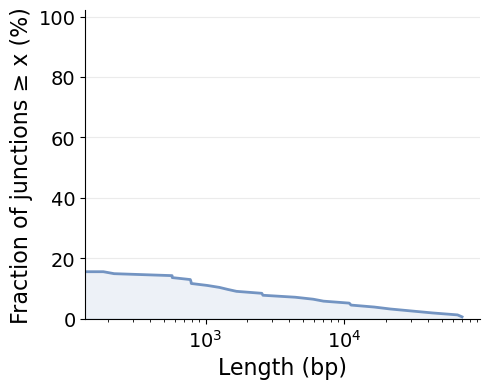

Saved figure to ../figures/2cluster_length_distr.pdf


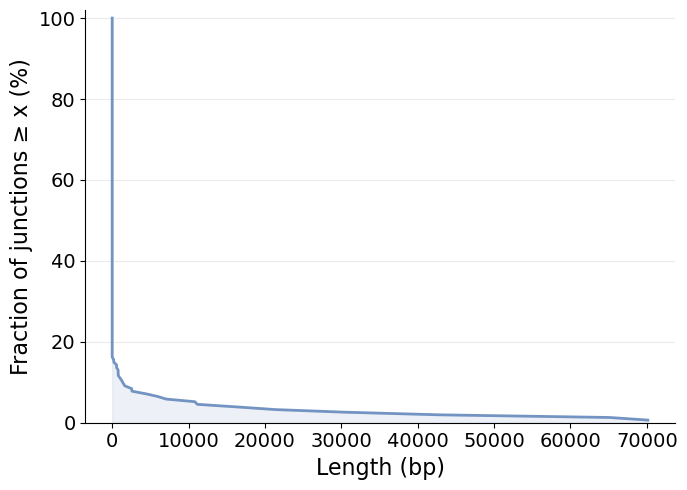

In [3]:
plot_path_comparison_lengths(path_comparison_df, histogram=False, log_x = True,
      cols=("exclusive_length",),                                                                                                                                                           
      labels=("exclusive",))

plot_path_comparison_lengths(path_comparison_df, histogram=False,
      cols=("exclusive_length",),                                                                                                                                                           
      labels=("exclusive",), figsize=(7,5), save_path="../figures/2cluster_length_distr.pdf")